In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.9 MB/s eta 0:00:0000:01


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


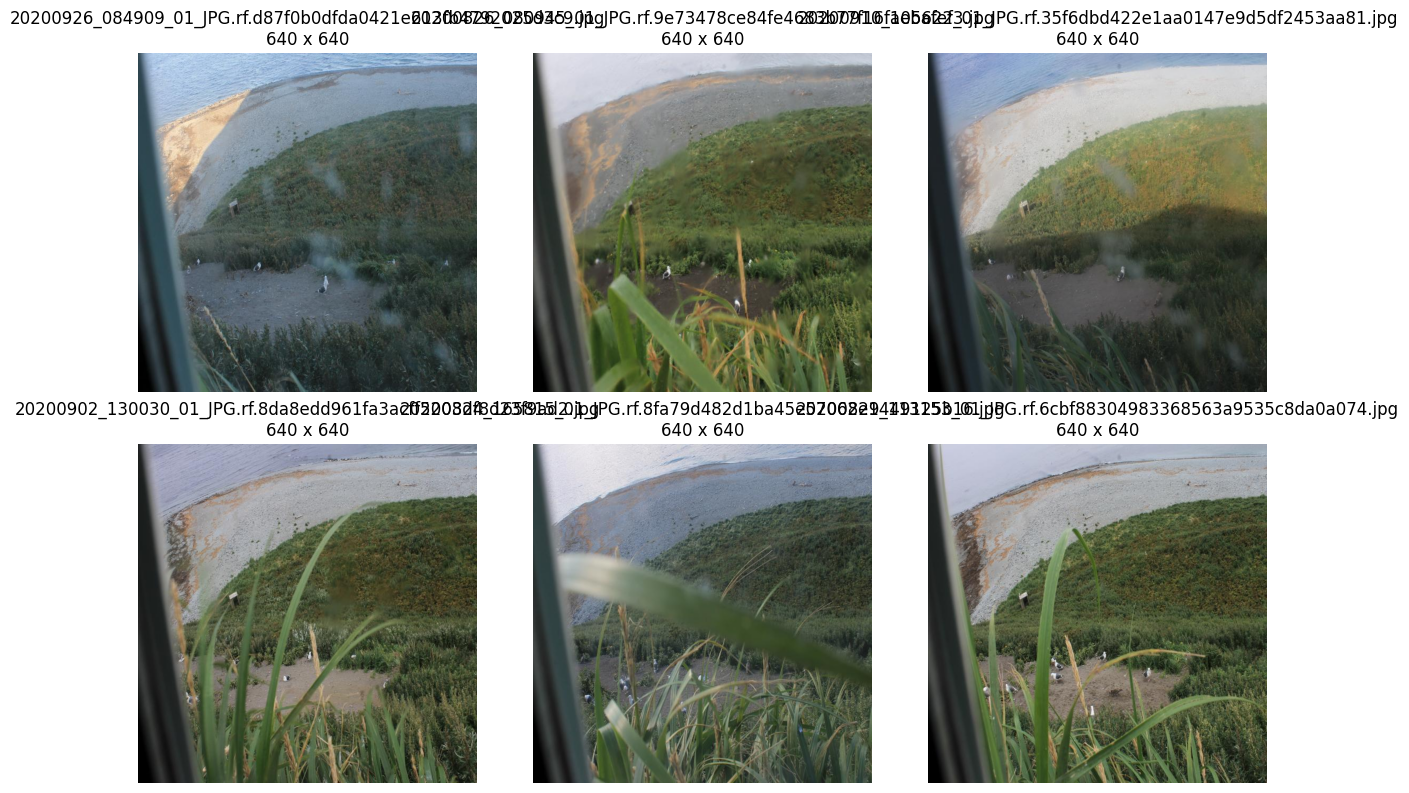


Размеры изображений:
20200926_084909_01_JPG.rf.d87f0b0dfda0421e613fb4792025d3c9.jpg: 640 x 640
20200826_080945_01_JPG.rf.9e73478ce84fe4683b77f16faebafef3.jpg: 640 x 640
20200910_105622_01_JPG.rf.35f6dbd422e1aa0147e9d5df2453aa81.jpg: 640 x 640
20200902_130030_01_JPG.rf.8da8edd961fa3acff5203df8d23f9ad2.jpg: 640 x 640
20200824_165815_01_JPG.rf.8fa79d482d1ba45e57062e1449125b16.jpg: 640 x 640
20200829_113153_01_JPG.rf.6cbf88304983368563a9535c8da0a074.jpg: 640 x 640


In [3]:
from ultralytics import YOLO
import os, shutil, pandas as pd
from pathlib import Path
import torch
import matplotlib.pyplot as plt
import cv2

train_images = "/kaggle/input/datasets/sluchevskiipersii/find-seagulls/data/train/images"
train_labels = "/kaggle/input/datasets/sluchevskiipersii/find-seagulls/data/train/labels"
test_images = "/kaggle/input/datasets/sluchevskiipersii/find-seagulls/data/test/images"

image_files = os.listdir(train_images)[:6]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, img_file in enumerate(image_files):
    img_path = os.path.join(train_images, img_file)
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h, w = img.shape[:2]
    
    axes[i].imshow(img)
    axes[i].set_title(f"{img_file}\n{w} x {h}")
    axes[i].axis('off')

plt.tight_layout()
plt.show()

print("\nРазмеры изображений:")
for img_file in image_files:
    img_path = os.path.join(train_images, img_file)
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        print(f"{img_file}: {w} x {h}")

In [3]:
yaml_content = f"""
path: /kaggle/input/datasets/sluchevskiipersii/find-seagulls/data
train: train/images
val: train/images
nc: 1
names: ['seagull']
"""

with open('/kaggle/working/dataset.yaml', 'w') as f:
    f.write(yaml_content)

dataset.yaml создан


In [4]:
model = YOLO('yolov8m.pt')
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 48, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(48, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(48, 96, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
      (act): SiLU(inplace=True)
    )
    (2): C2f(
      (cv1): Conv(
        (conv): Conv2d(96, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(192, 96, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn): BatchNorm2d(96, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
   

In [7]:
results = model.train(
    data    = '/kaggle/working/dataset.yaml',
    epochs  = 50,
    imgsz   = 640,
    batch   = 16,
    device  = 0,           # GPU
    project = '/kaggle/working/runs',
    name    = 'seagull',
    patience= 10,          # early stopping
)

Ultralytics 8.4.45 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/dataset.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=seagull, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=10, pe

In [8]:
from ultralytics import YOLO

model = YOLO('/kaggle/working/runs/seagull/weights/best.pt')

test_files = sorted(os.listdir(test_images))
results_list = []

for i, fname in enumerate(test_files):
    img_path = os.path.join(test_images, fname)
    
    result = model(img_path, conf=0.25, verbose=False)[0]
    
    boxes = result.boxes
    
    if boxes is None or len(boxes) == 0:
        bbox_str = '-1'
    else:
        parts = []
        for box in boxes:
            # xywhn — нормированные x_center, y_center, width, height
            x, y, w, h = box.xywhn[0].tolist()
            parts.append(f"0 {x:.6f} {y:.6f} {w:.6f} {h:.6f}")
        bbox_str = ' '.join(parts)
    
    results_list.append({
        'index':    i,
        'filename': fname,
        'bbox':     bbox_str
    })

df = pd.DataFrame(results_list)
df.to_csv('/kaggle/working/submission.csv', index=False)
print(df.head())
print(f"Всего: {len(df)} изображений")

   index                                           filename bbox
0      0  20200928_150507_01_JPG.rf.109359154a680b75a67d...   -1
1      1  20200928_160525_01_JPG.rf.50f3289f065a9a4f5372...   -1
2      2  20200928_180600_01_JPG.rf.df87e688ee0e009c3a06...   -1
3      3  20200929_081017_01_JPG.rf.c0e8134223d6ed61ac51...   -1
4      4  20200929_091035_01_JPG.rf.cc0f7b275eb3a5dd680d...   -1
Всего: 99 изображений
